,Player,Position,Team,Season
0,Mo Bamba,C,Los Angeles Lakers,2022-23
1,Malik Beasley,G,Los Angeles Lakers,2022-23
2,Troy Brown Jr.,G/F,Los Angeles Lakers,2022-23
3,Max Christie,G/F,Los Angeles Lakers,2022-23
4,Anthony Davis,F/C,Los Angeles Lakers,2022-23
5,Wenyen Gabriel,F/C,Los Angeles Lakers,2022-23
6,Rui Hachimura,F,Los Angeles Lakers,2022-23
7,Shaquille Harrison,G,Los Angeles Lakers,2022-23
8,LeBron James,F,Los Angeles Lakers,2022-23
9,Scotty Jr. Pippen,G,Los Angeles Lakers,2022-23


,Player,Unique Teammates,Weighted Connections,Degree Centrality,Betweenness Centrality,PageRank,Teams,Number of Teams,Seasons,Position
0,Thomas Bryant,33,33,0.266129,0.144243,0.010194,"Denver Nuggets, Miami Heat",2,"2022-23, 2023-24","C, F/C"
1,Cole Swider,33,33,0.266129,0.097060,0.010989,"Los Angeles Lakers, Miami Heat",2,"2022-23, 2023-24",F
2,Gabe Vincent,33,33,0.266129,0.056363,0.011043,"Los Angeles Lakers, Miami Heat",2,"2022-23, 2023-24",G
3,Max Christie,27,33,0.217742,0.004703,0.011549,Los Angeles Lakers,1,"2022-23, 2023-24","G, G/F"
4,Anthony Davis,27,33,0.217742,0.004703,0.011549,Los Angeles Lakers,1,"2022-23, 2023-24",F/C
5,Rui Hachimura,27,33,0.217742,0.004703,0.011549,Los Angeles Lakers,1,"2022-23, 2023-24",F
6,LeBron James,27,33,0.217742,0.004703,0.011549,Los Angeles Lakers,1,"2022-23, 2023-24",F
7,Austin Reaves,27,33,0.217742,0.004703,0.011549,Los Angeles Lakers,1,"2022-23, 2023-24",G
8,D'Angelo Russell,27,33,0.217742,0.004703,0.011549,Los Angeles Lakers,1,"2022-23, 2023-24",G
9,Jarred Vanderbilt,27,33,0.217742,0.004703,0.011549,Los Angeles Lakers,1,"2022-23, 2023-24",F


Roster rows: 173
Nodes: 125
Edges: 1223
Connected components: 3
Self-loops: 0
Duplicate roster rows: 0

Players per team and season:
Season   Team                 
2022-23  Boston Celtics           17
         Denver Nuggets           17
         Golden State Warriors    17
         Los Angeles Lakers       17
         Miami Heat               17
2023-24  Boston Celtics           17
         Denver Nuggets           18
         Golden State Warriors    17
         Los Angeles Lakers       18
         Miami Heat               18
Name: Player, dtype: int64


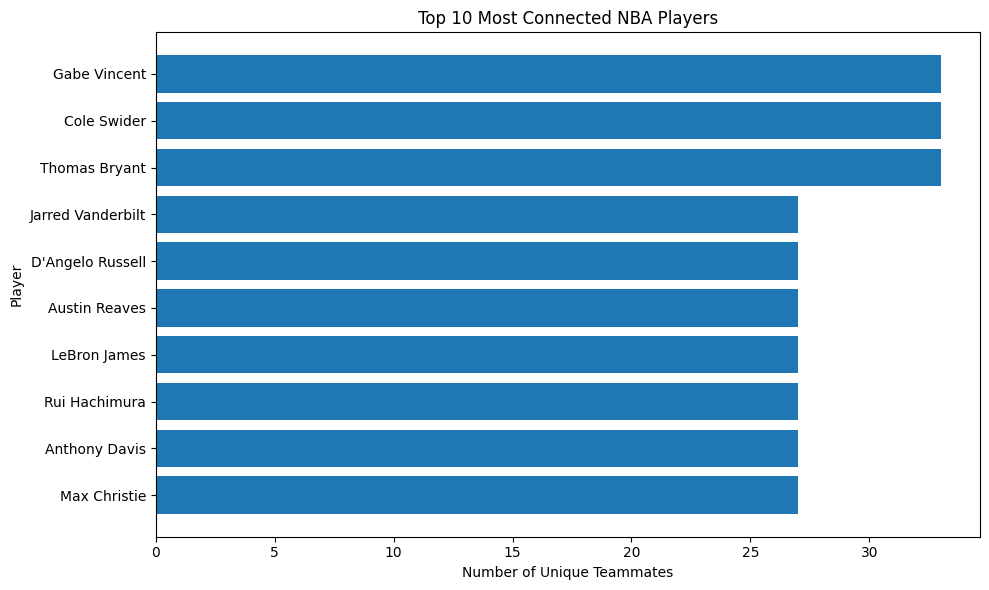

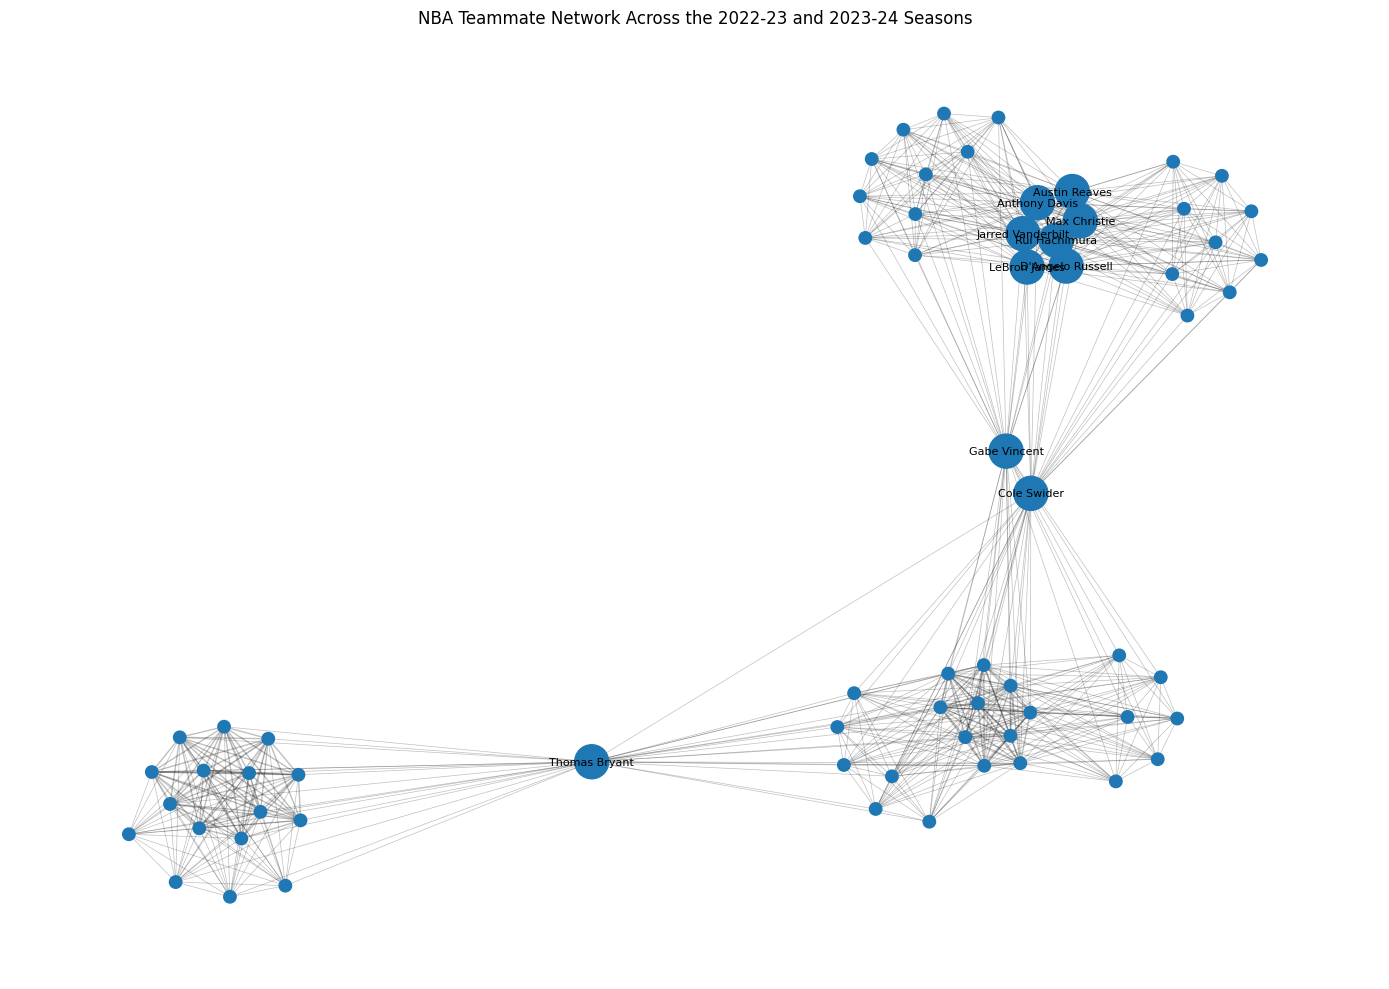

In [2]:
import pandas as pd
import requests
import networkx as nx
import matplotlib.pyplot as plt
from io import StringIO
from itertools import combinations

headers = {"User-Agent": "BasketballNetworkClassProject/1.0 student research"}

teams = {
    ("Los Angeles Lakers", "2022-23"): "https://en.wikipedia.org/wiki/2022%E2%80%9323_Los_Angeles_Lakers_season",
    ("Los Angeles Lakers", "2023-24"): "https://en.wikipedia.org/wiki/2023%E2%80%9324_Los_Angeles_Lakers_season",
    ("Boston Celtics", "2022-23"): "https://en.wikipedia.org/wiki/2022%E2%80%9323_Boston_Celtics_season",
    ("Boston Celtics", "2023-24"): "https://en.wikipedia.org/wiki/2023%E2%80%9324_Boston_Celtics_season",
    ("Golden State Warriors", "2022-23"): "https://en.wikipedia.org/wiki/2022%E2%80%9323_Golden_State_Warriors_season",
    ("Golden State Warriors", "2023-24"): "https://en.wikipedia.org/wiki/2023%E2%80%9324_Golden_State_Warriors_season",
    ("Denver Nuggets", "2022-23"): "https://en.wikipedia.org/wiki/2022%E2%80%9323_Denver_Nuggets_season",
    ("Denver Nuggets", "2023-24"): "https://en.wikipedia.org/wiki/2023%E2%80%9324_Denver_Nuggets_season",
    ("Miami Heat", "2022-23"): "https://en.wikipedia.org/wiki/2022%E2%80%9323_Miami_Heat_season",
    ("Miami Heat", "2023-24"): "https://en.wikipedia.org/wiki/2023%E2%80%9324_Miami_Heat_season"
}

all_rosters = []

for (team, season), url in teams.items():
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    tables = pd.read_html(StringIO(response.text))
    roster = None

    for table in tables:
        test = table.copy()
        test.columns = [
            " ".join(str(x) for x in col if str(x).lower() != "nan").strip()
            if isinstance(col, tuple)
            else str(col).strip()
            for col in test.columns
        ]

        player_columns = [col for col in test.columns if "player" in col.lower()]

        if player_columns:
            player_col = player_columns[0]
            player_values = test[player_col].astype(str).str.strip()

            if player_values.nunique() >= 8:
                roster = test
                break

    if roster is None:
        print("Roster not found:", team, season)
        continue

    position_columns = [col for col in roster.columns if "pos" in col.lower()]

    if position_columns:
        roster = roster[[player_col, position_columns[0]]].copy()
        roster.columns = ["Player", "Position"]
    else:
        roster = roster[[player_col]].copy()
        roster.columns = ["Player"]
        roster["Position"] = "Unknown"

    roster["Team"] = team
    roster["Season"] = season
    all_rosters.append(roster)

if not all_rosters:
    raise ValueError("No roster tables were found.")

players_df = pd.concat(all_rosters, ignore_index=True)

players_df["Player"] = (
    players_df["Player"]
    .astype(str)
    .str.replace(r"\[[^\]]+\]", "", regex=True)
    .str.replace(r"\s*\(.*?\)", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

players_df["Position"] = players_df["Position"].astype(str).str.strip()

players_df = players_df[
    players_df["Player"].notna()
    & (players_df["Player"] != "")
    & (players_df["Player"].str.lower() != "nan")
    & (players_df["Player"].str.lower() != "player")
]

players_df = players_df.drop_duplicates(
    subset=["Player", "Team", "Season"]
).reset_index(drop=True)

G = nx.Graph()

for (team, season), group in players_df.groupby(["Team", "Season"]):
    players = group["Player"].dropna().unique()

    for player in players:
        if player not in G:
            G.add_node(player, teams=set(), seasons=set())
        G.nodes[player]["teams"].add(team)
        G.nodes[player]["seasons"].add(season)

    for player1, player2 in combinations(players, 2):
        if G.has_edge(player1, player2):
            G[player1][player2]["weight"] += 1
        else:
            G.add_edge(player1, player2, weight=1)

degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G, weight="weight")

results = pd.DataFrame({
    "Player": list(G.nodes()),
    "Unique Teammates": [degree[player] for player in G.nodes()],
    "Weighted Connections": [weighted_degree[player] for player in G.nodes()],
    "Degree Centrality": [degree_centrality[player] for player in G.nodes()],
    "Betweenness Centrality": [betweenness[player] for player in G.nodes()],
    "PageRank": [pagerank[player] for player in G.nodes()],
    "Teams": [", ".join(sorted(G.nodes[player]["teams"])) for player in G.nodes()],
    "Number of Teams": [len(G.nodes[player]["teams"]) for player in G.nodes()],
    "Seasons": [", ".join(sorted(G.nodes[player]["seasons"])) for player in G.nodes()]
})

positions = (
    players_df.groupby("Player")["Position"]
    .agg(lambda x: ", ".join(sorted(set(x))))
    .reset_index()
)

results = results.merge(positions, on="Player", how="left")

results = results.sort_values(
    ["Unique Teammates", "Betweenness Centrality", "PageRank"],
    ascending=False
).reset_index(drop=True)

top10 = results.head(10)

display(players_df.head(20))
display(top10)

print("Roster rows:", len(players_df))
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))
print("Self-loops:", nx.number_of_selfloops(G))
print("Duplicate roster rows:", players_df.duplicated(["Player", "Team", "Season"]).sum())
print("\nPlayers per team and season:")
print(players_df.groupby(["Season", "Team"])["Player"].nunique())

players_df.to_csv("nba_rosters.csv", index=False)
results.to_csv("nba_network_results.csv", index=False)
top10.to_csv("top_10_important_nba_players.csv", index=False)

top10_plot = top10.sort_values("Unique Teammates")

plt.figure(figsize=(10, 6))
plt.barh(top10_plot["Player"], top10_plot["Unique Teammates"])
plt.xlabel("Number of Unique Teammates")
plt.ylabel("Player")
plt.title("Top 10 Most Connected NBA Players")
plt.tight_layout()
plt.savefig("top_10_connected_players.png", dpi=300)
plt.show()

important_players = set(top10["Player"])
network_nodes = set(important_players)

for player in important_players:
    network_nodes.update(G.neighbors(player))

subgraph = G.subgraph(network_nodes)
pos = nx.spring_layout(subgraph, seed=42, weight="weight")

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=[
        600 if node in important_players else 80
        for node in subgraph.nodes()
    ]
)

nx.draw_networkx_edges(
    subgraph,
    pos,
    width=[
        subgraph[u][v]["weight"] * 0.5
        for u, v in subgraph.edges()
    ],
    alpha=0.25
)

nx.draw_networkx_labels(
    subgraph,
    pos,
    labels={node: node for node in important_players},
    font_size=8
)

plt.title("NBA Teammate Network Across the 2022-23 and 2023-24 Seasons")
plt.axis("off")
plt.tight_layout()
plt.savefig("nba_teammate_network.png", dpi=300)
plt.show()